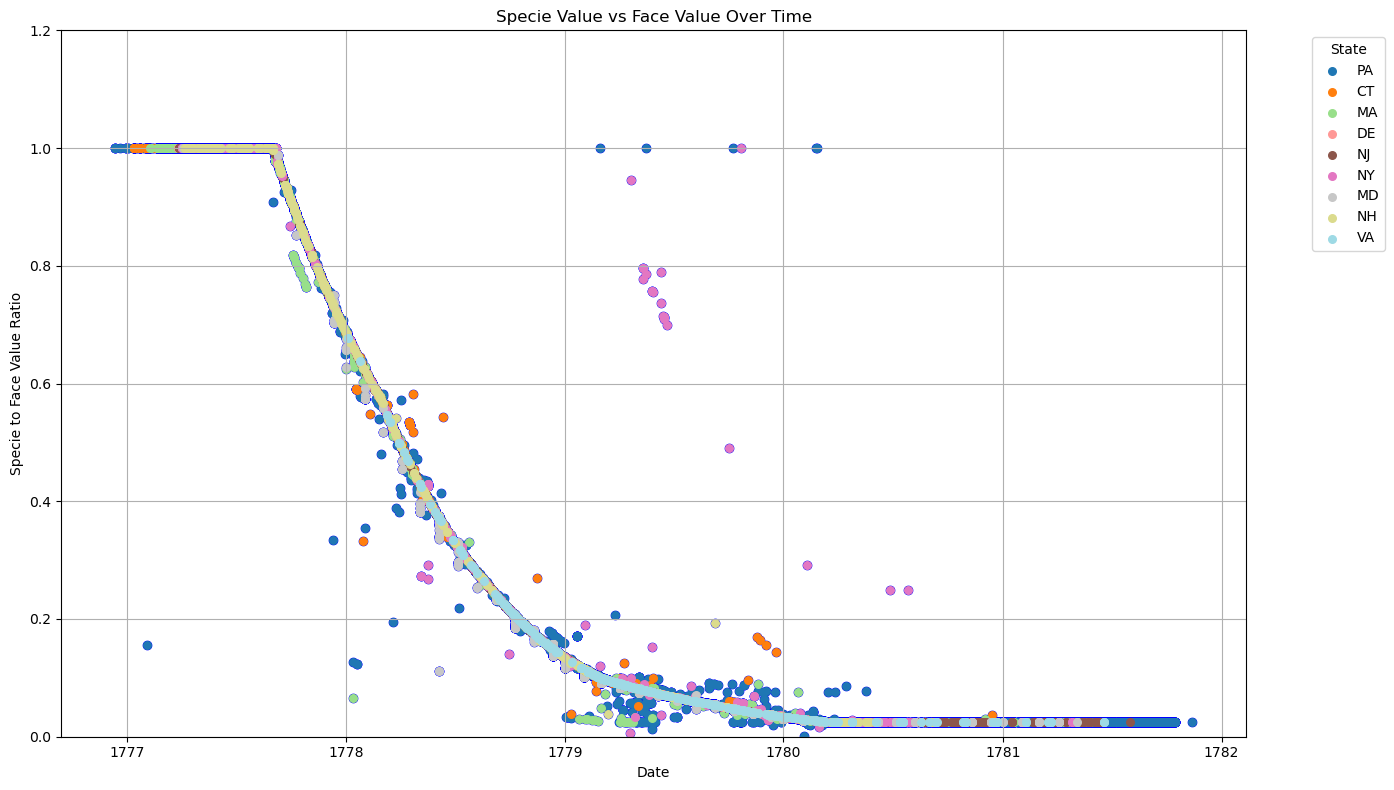

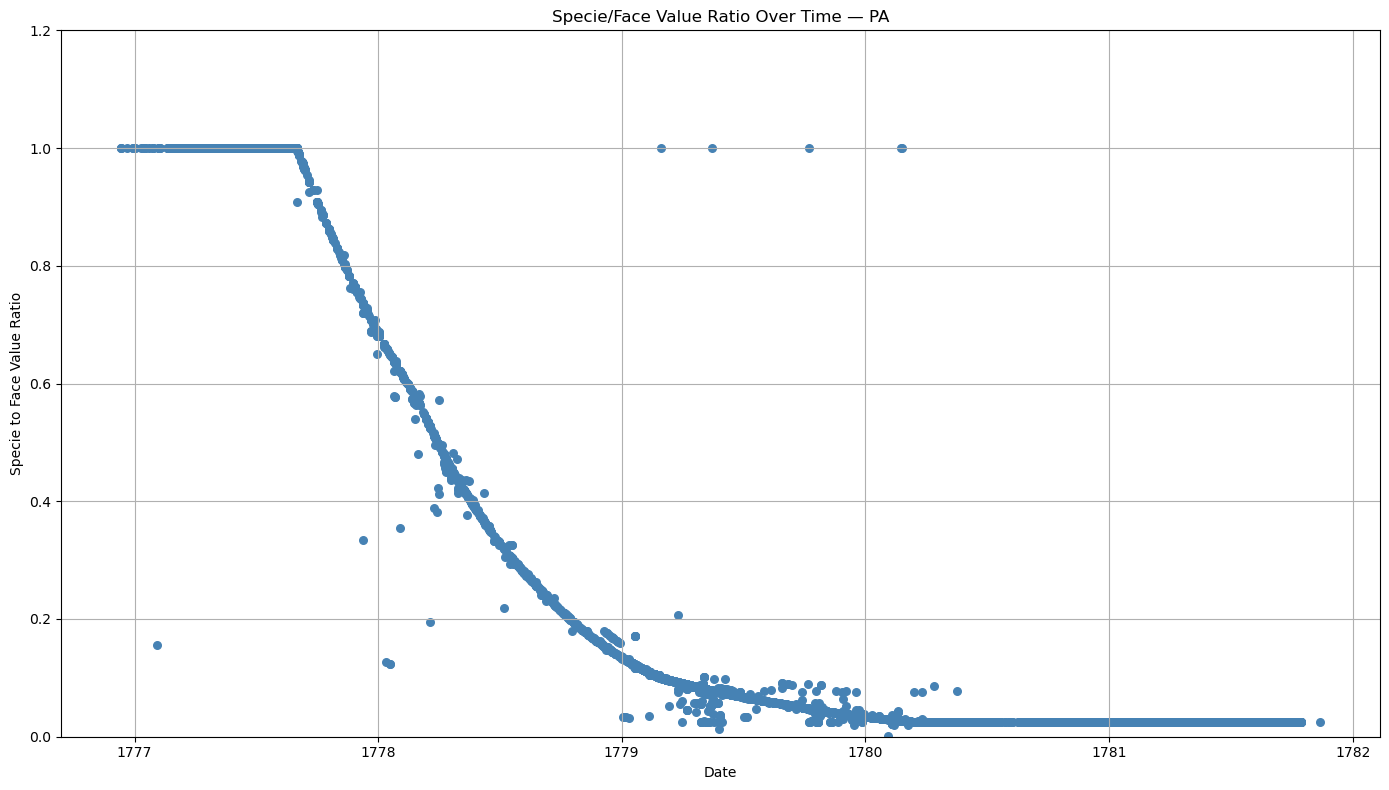

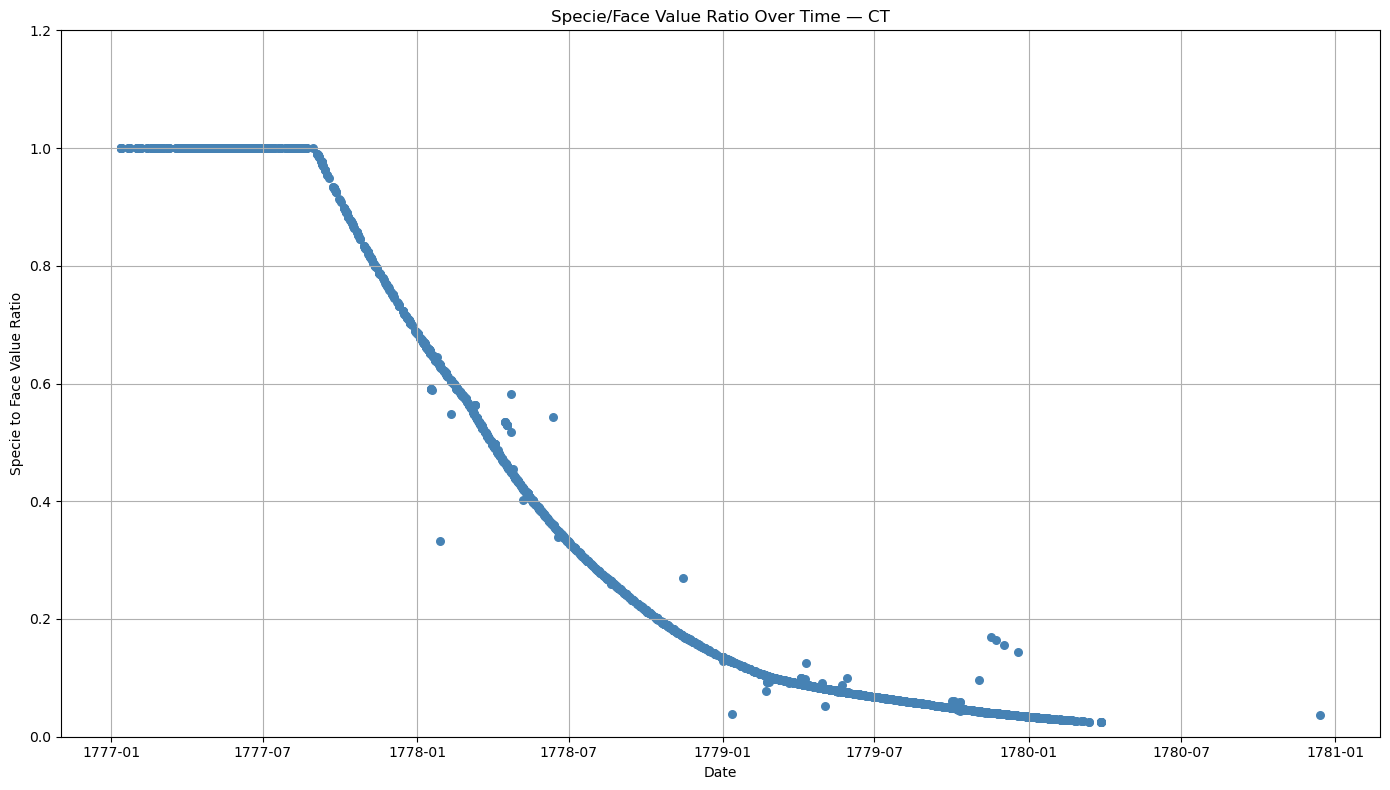

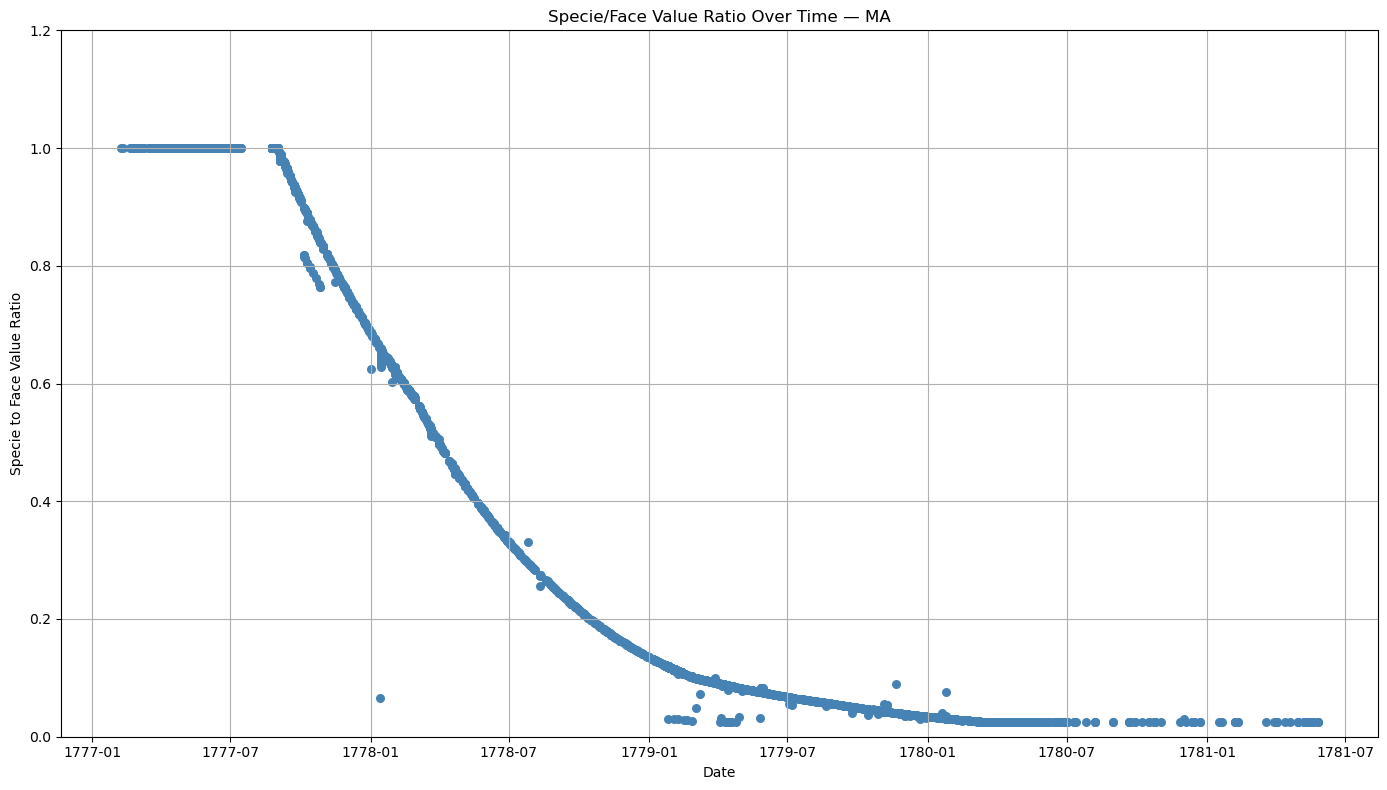

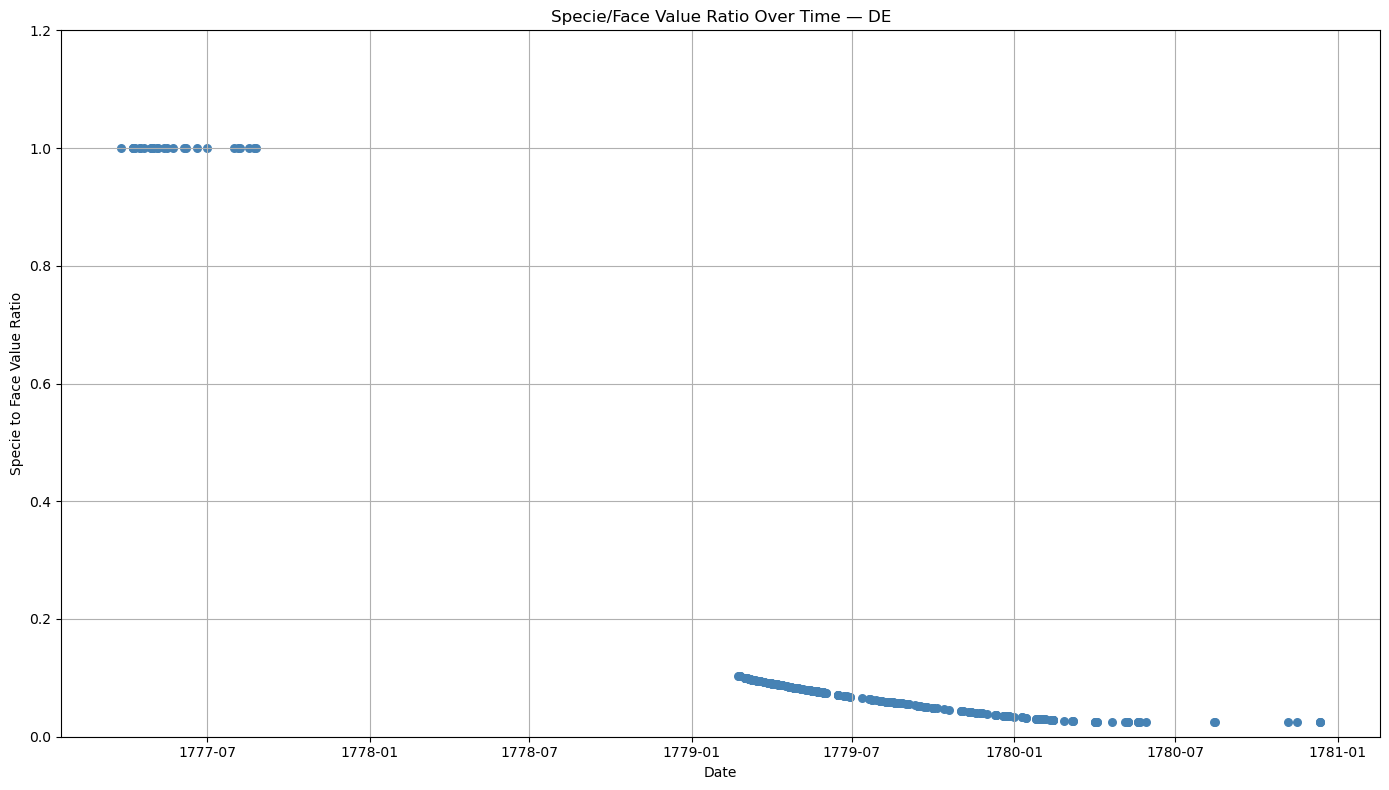

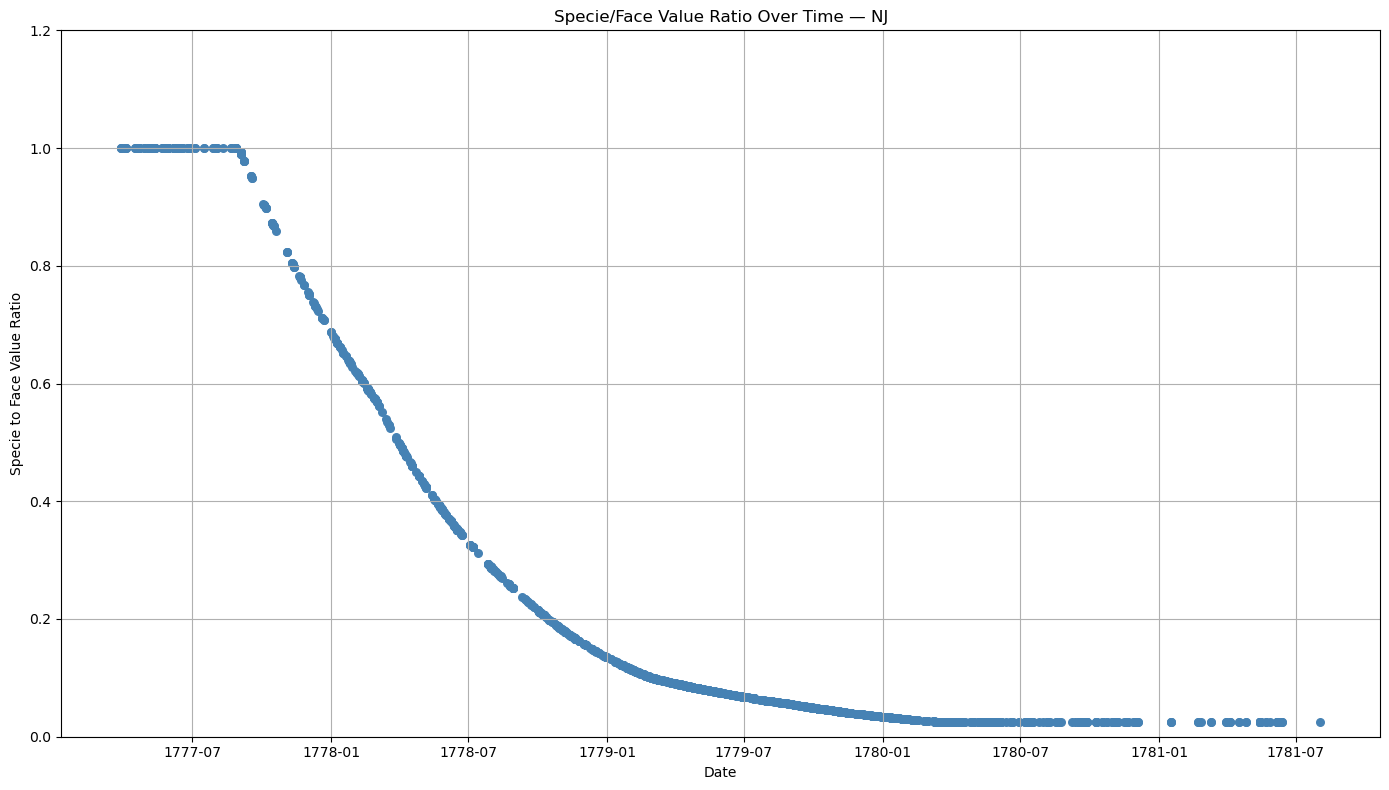

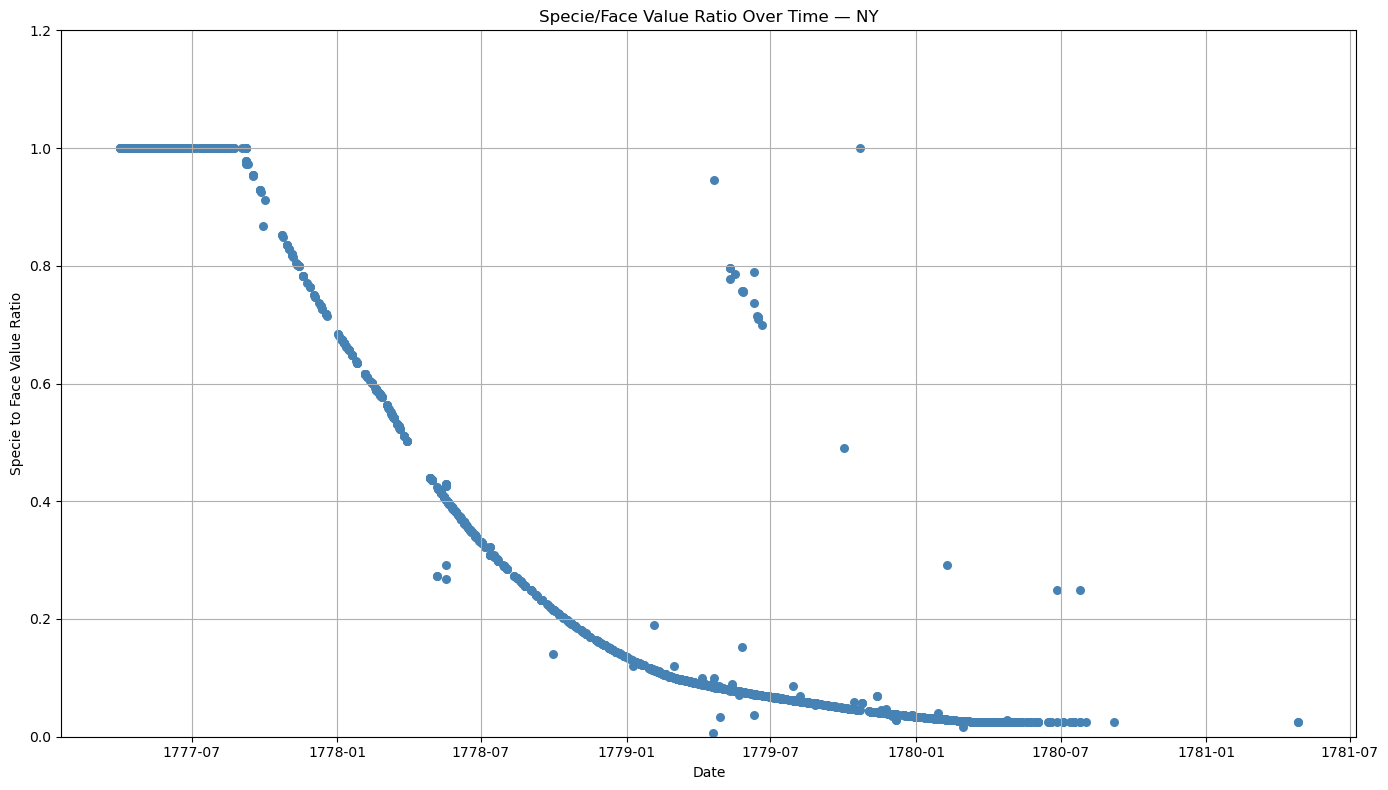

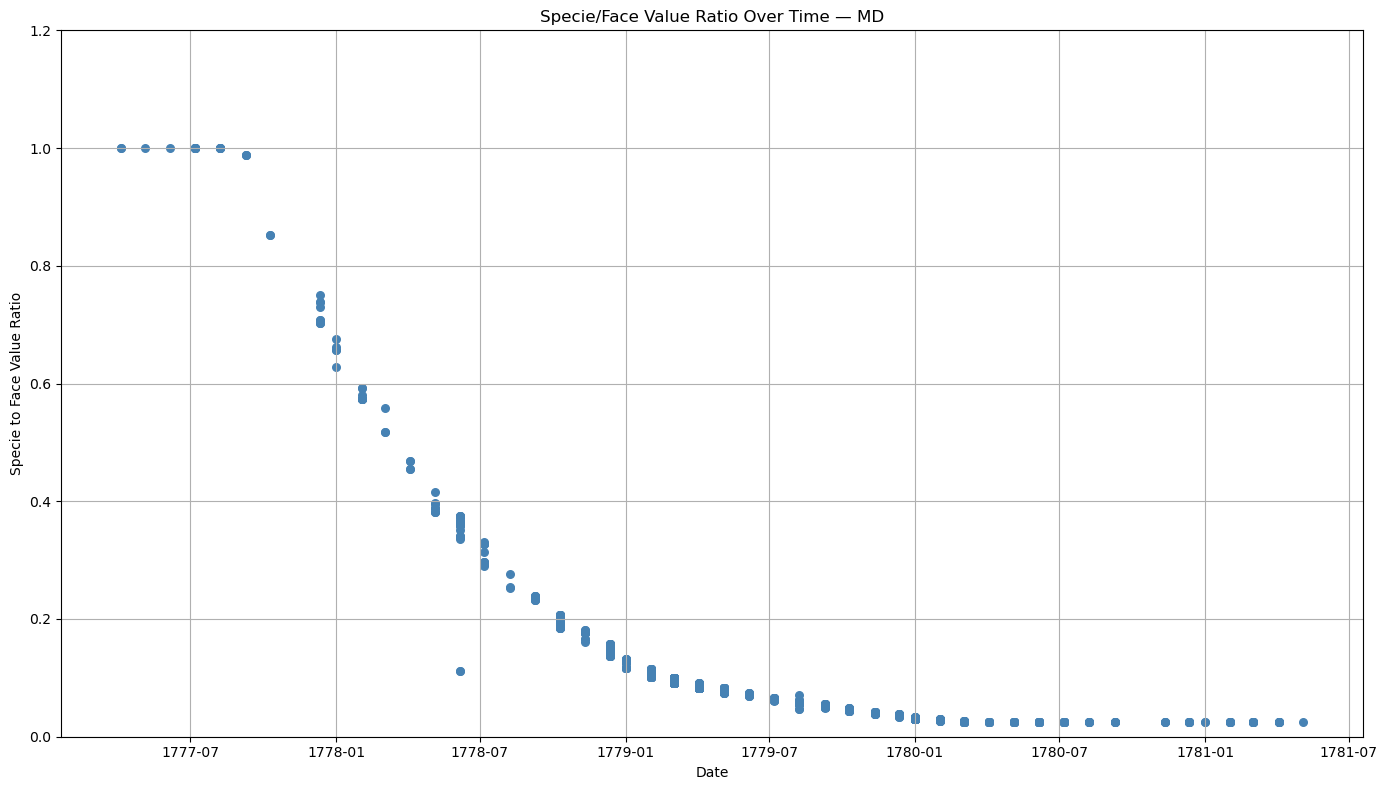

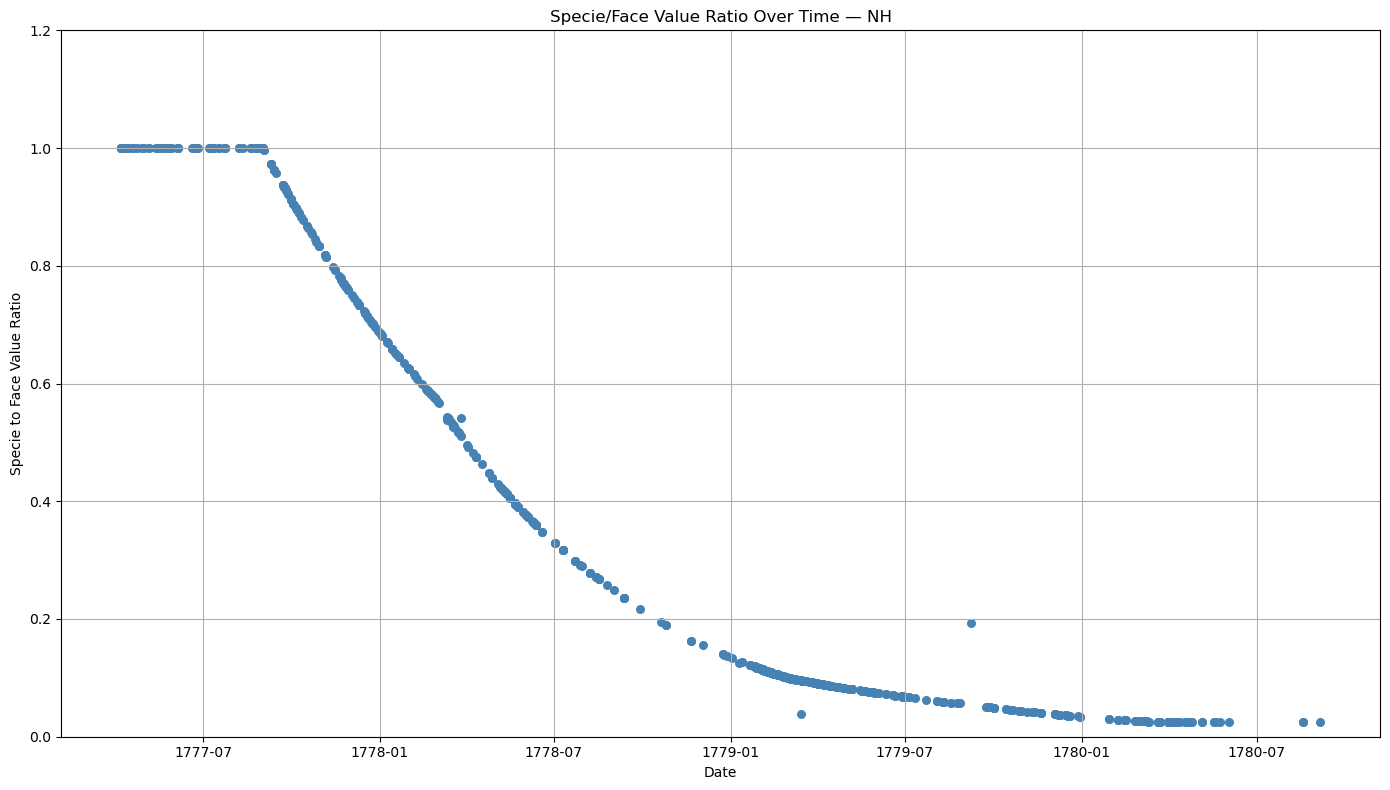

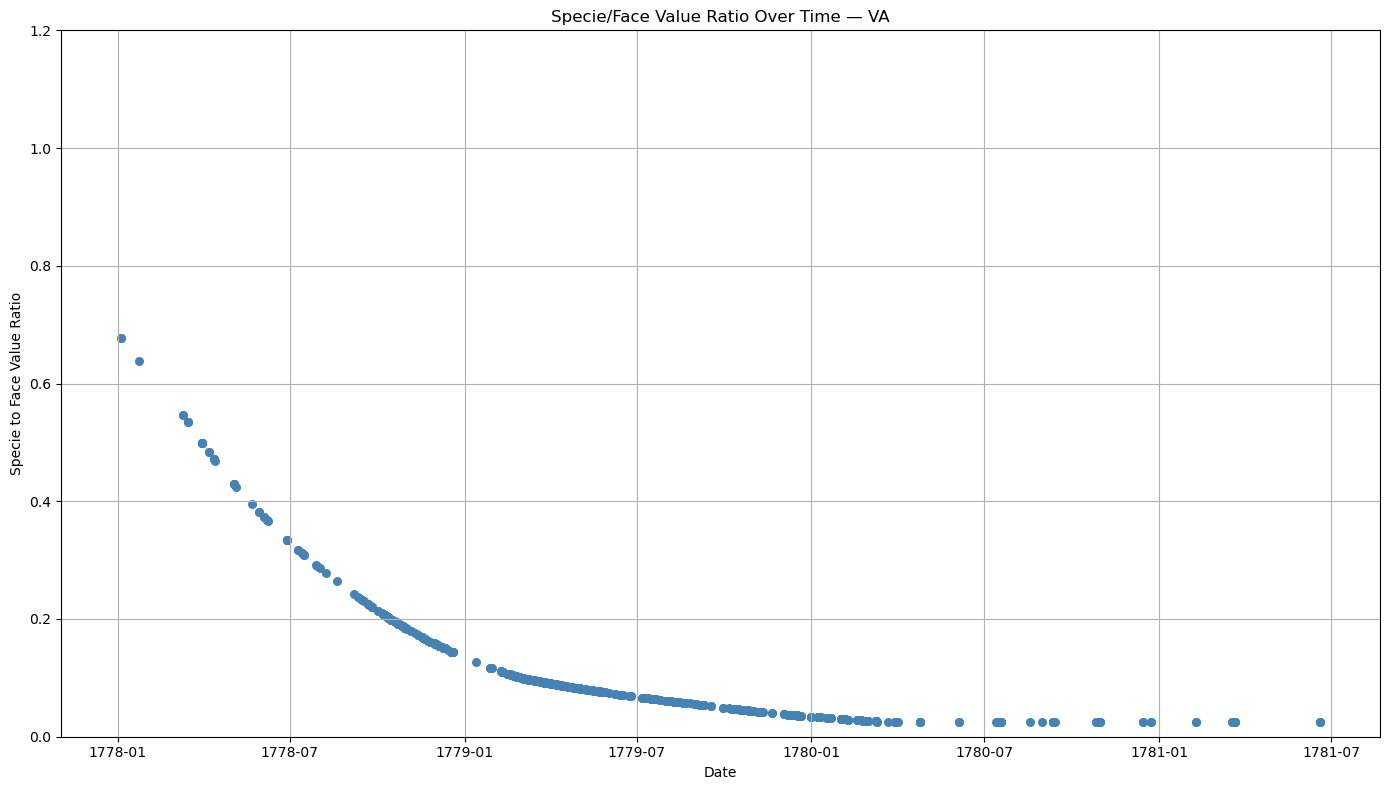

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# read CSV
input_csv = "loan_office_certificates_cleaned.csv"
df = pd.read_csv(input_csv, usecols=["raw_name", "state", "Year", "Month", "Day", "Face Value", "Specie Value"], low_memory=False)

# clean
df = df.dropna(subset=["Year", "Month", "Day"])
df = df.drop_duplicates()

# create datetime objects
# fix columns
df["Year"] = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)
df["Day"] = df["Day"].astype(int)

df["date"] = pd.to_datetime(df[["Year", "Month", "Day"]], errors='coerce')
# Drop rows with invalid dates (NaT)
df = df.dropna(subset=["date"])

# set ratios
df["ratio"] = df["Specie Value"] / df["Face Value"]

# sort
df = df.sort_values("date")

# create plot
plt.figure(figsize=(14, 8))
plt.scatter(df["date"], df["ratio"], marker='o', color='blue')

# generate color map
states = df["state"].unique()
colors = plt.get_cmap("tab20", len(states))

# plot each state
for i, state in enumerate(states):
    group = df[df["state"] == state]
    plt.scatter(group["date"], group["ratio"], label=state, color=colors(i), s=30)

# create labels & legend
plt.xlabel("Date")
plt.ylim(0,1.2)
plt.ylabel("Specie to Face Value Ratio")
plt.title("Specie Value vs Face Value Over Time")
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# create one plot per state
for state in states:
    state_df = df[df["state"] == state]

    plt.figure(figsize=(14, 8))
    plt.scatter(state_df["date"], state_df["ratio"], color="steelblue", s=30)

    plt.ylim(0,1.2)
    plt.title(f"Specie/Face Value Ratio Over Time — {state}")
    plt.xlabel("Date")
    plt.ylabel("Specie to Face Value Ratio")
    plt.grid(True)
    plt.tight_layout()
    plt.show()